In [1]:
# pip install sktime
import numpy as np
import pandas as pd

# Increase display width
pd.set_option("display.width", 1000)

# steps 1, 2 - prepare osuleaf dataset (train and new)
from sktime.datasets import load_italy_power_demand

X_train, y_train = load_italy_power_demand(split="train", return_type="numpy3D")
X_test, y_test = load_italy_power_demand(split="test", return_type="numpy3D")

In [2]:
# step 3 - specify the classifier
from sktime.classification.distance_based import KNeighborsTimeSeriesClassifier

# example 1 - 3-NN with simple dynamic time warping distance (requires numba)
clf = KNeighborsTimeSeriesClassifier(n_neighbors=3)

# example 2 - custom distance:
# 3-nearest neighbour classifier with Euclidean distance (on flattened time series)
# (requires scipy)
from sktime.classification.distance_based import KNeighborsTimeSeriesClassifier
from sktime.dists_kernels import FlatDist, ScipyDist

eucl_dist = FlatDist(ScipyDist())
clf = KNeighborsTimeSeriesClassifier(n_neighbors=3, distance=eucl_dist)

In [3]:
# step 4 - fit/train the classifier
clf.fit(X_train, y_train)

KNeighborsTimeSeriesClassifier(distance=FlatDist(transformer=ScipyDist()),
                               n_neighbors=3)

In [4]:
# create some predictions so we can get metrics
predictions = clf.predict(X_test)

In [5]:
import numpy as np

# loop through test data and compare predictions to real values
# the model seems to work pretty well!
for x in range(19):
    test_signal = X_test[x]
    test_signal = np.expand_dims(test_signal, axis=0)
    result = clf.predict(test_signal)
    index = result[0]

    print(f"Predicted by model: {result}")
    print(f"Real value in dataset: {y_test[x]}")
    print("----------------------")
        

Predicted by model: ['2']
Real value in dataset: 2
----------------------
Predicted by model: ['2']
Real value in dataset: 2
----------------------
Predicted by model: ['2']
Real value in dataset: 2
----------------------
Predicted by model: ['2']
Real value in dataset: 2
----------------------
Predicted by model: ['2']
Real value in dataset: 2
----------------------
Predicted by model: ['1']
Real value in dataset: 1
----------------------
Predicted by model: ['2']
Real value in dataset: 2
----------------------
Predicted by model: ['2']
Real value in dataset: 2
----------------------
Predicted by model: ['2']
Real value in dataset: 2
----------------------
Predicted by model: ['2']
Real value in dataset: 2
----------------------
Predicted by model: ['2']
Real value in dataset: 2
----------------------
Predicted by model: ['2']
Real value in dataset: 2
----------------------
Predicted by model: ['2']
Real value in dataset: 2
----------------------
Predicted by model: ['1']
Real value i

Predicted by model: ['1']
Real value in dataset: 1
----------------------


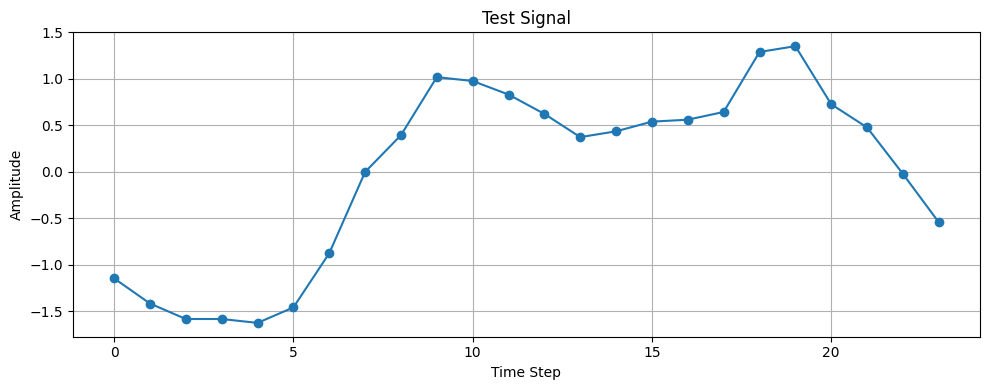

In [6]:
import numpy as np
import matplotlib.pyplot as plt


# try predicting only on certain test signal
# and also plot the signal
x = 5
test_signal = X_test[x]
test_signal = np.expand_dims(test_signal, axis=0)
result = clf.predict(test_signal)
index = result[0]

print(f"Predicted by model: {result}")
print(f"Real value in dataset: {y_test[x]}")
print("----------------------")


# Flatten the array (in case it's 3D as shown)
flattened_signal = test_signal.flatten()

# Plot the signal
plt.figure(figsize=(10, 4))
plt.plot(flattened_signal, marker='o')
plt.title('Test Signal')
plt.xlabel('Time Step')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()


#### Some usual classification metrics

In [7]:
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
import seaborn as sns

# print the classification report based on true values and predictions
print(classification_report(y_test, predictions))

# get overall accuracy of the model and print it
acc = accuracy_score(y_test, predictions)
print("\nModel overall accuracy: {:.2f}%".format(acc * 100))

              precision    recall  f1-score   support

           1       0.96      0.95      0.96       513
           2       0.95      0.96      0.96       516

    accuracy                           0.96      1029
   macro avg       0.96      0.96      0.96      1029
weighted avg       0.96      0.96      0.96      1029


Model overall accuracy: 95.63%


[[489  24]
 [ 21 495]]


<Axes: >

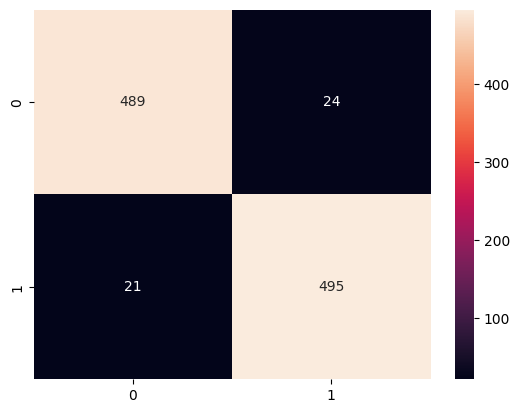

In [8]:
print(confusion_matrix(y_test, predictions))

# if you want a more graphical version of this, try:
# the fmt-parameter will change to decimal format from scientific format
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='g')